# Chapter 1: Introduction to Objects

## Notes

- Object-Oriented Programming is a design paradigm that structures code
  around classes and their associated object instances
- Classes combine state (attributes) and functions on that state
  (methods)
- Pretty much everything in python is an object in the OOP sense
  - They have methods that operate on them
- For example, the `list` class has a method `pop` which removes
  elements from the list

In [1]:
a_list = [5, 20, 15, 6, 123]
value = a_list.pop()
print(value)

123

### Classes

- Python lets you define classes of your own via the `class` keyword
  - Classes can then be *instantiated* to create new *object instances*
- All instance methods in python must accept a `self` parameter as the
  first argument, referencing the object the method is invoked on
  - This is passed implicitly and does not need to be included in the
    method call

In [2]:
class Employee:
    def __init__(self, first_name, last_name, salary):
        self.id = -1 # placeholder value
        self.first_name = first_name
        self.last_name = last_name
        self._salary  = salary
        self.benefits = 1000

    def get_salary(self):
        return self._salary

alice = Employee("Alice", "A", 10_000)
bob = Employee("Bob", "B", 8_000)

print(f"alice:", alice)
print(f"bob.get_salary():", bob.get_salary())

alice: <__main__.Employee object at 0x7f69446af380>
bob.get_salary(): 8000

- For example above defines an `Employee` class representing someone
  employed at a company.
  - The class contains *public* `id`, `first_name`, `last_name` and
    `benefits` and a *protected* `_salary` attribute
  - The class also defines a method `get_salary` to access the protected
    `_salary` variable

#### The `__init__` Method

- `__init__` is called whenever a new instance of a class is created
- Each class can only define *one* `__init__` method
  - This contrasts to other languages which can sometimes allow for
    multiple constructor signatures
- `__init__` is used for populating the initial state of an object
- In the example above, `alice` and `bob` both are populated via the
  `__init__` method

#### Class Instance Attributes

- Python does not provide true public and private variable encapsulation
  rules as in many other languages
- Instead by convention a leading `_` denotes a method or attribute that
  is not intended to be accessed outside the class it is defined on
  - In the `Employee` example above we can see `_salary` is protected
- Protected variables are good when you need to maintain internal
  constraints or don’t want to provide guarantees about the stability of
  an API

### Collections of Classes

- Often it is useful to define higher-order container classes that are
  designed to provide simple interfaces to queries over a collection of
  a given class type
- For example, rather than using a naked list we might want to group our
  `Employee` instances up into an `Employees` collection object

In [3]:
class Employees:
    def __init__(self):
        self.employee_dict = {}  # create an empty dictionary
        self._next_id = 1

    def add_employee(self, employee):

        employee.id = self._next_id
        self._next_id += 1

        self.employee_dict[employee.id] = employee

    def list_employees(self):
        for employee_id in self.employee_dict:
            employee = self.employee_dict[employee_id]
            print(f"{employee_id}: {employee.last_name}, {employee.first_name}")


employees = Employees()
employees.add_employee(alice)
employees.add_employee(bob)

employees.list_employees()
print("alice.id:", alice.id)

1: A, Alice
2: B, Bob
alice.id: 1

- The `Employees` collection class automatically handles assigning new
  id’s to `Employee` objects as they are added to the collection via the
  `add_employee` method
  - Thus can enforce more structure than a bare list or dictionary

### Inheritance

- Python provides support for standard class inheritance
- Must use `super()` to invoke methods on the parent
  - Must commonly used to invoke the parent `__init__` when a child
    `__init__` is invoked
- For example, we might define a `TempEmployee`
  - As an `Employee` but has no benefits and has a contract end-date

In [4]:
from datetime import datetime, timedelta


class TempEmployee(Employee):
    def __init__(self, first_name, last_name, salary, contract_end_date):
        super().__init__(first_name, last_name, salary)
        self.benefits = 0
        self.end_date = contract_end_date

    def contract_period_left(self):
        return self.end_date - datetime.now()


charlie = TempEmployee("Charlie", "C", 20_000, datetime.now() + timedelta(days=10))
print("Charlie has", charlie.contract_period_left(), "until their contract expires")

Charlie has 9 days, 23:59:59.999950 until their contract expires

#### Overriding Methods

- Subclasses can override methods and attributes of their parent by
  redefining the method
- By default Python method resolution first looks on the most-derived
  class of an object, then walks up the hierarchy until the method is
  found
- For example, we might define an `HourlyWorker` class
  - Rather than having a salary they have an hourly wage and average
    hours
  - Salary is then *estimated* from their wage and hours
    - Do this by overriding the `get_salary` method

In [5]:
class HourlyWorker(Employee):
    def __init__(self, first_name, last_name, hourly_rate, average_hours):
        super().__init__(first_name, last_name, hourly_rate)
        self.average_hours = average_hours

    def get_salary(self):
        return self.average_hours * super().get_salary()


dani = HourlyWorker("Dani", "D", 35, 60)
print("Dani's estimated salary is:", dani.get_salary())

Dani's estimated salary is: 2100

#### Multiple Inheritance

- Python supports multiple inheritance
  - This is not universal across OOP languages
- This sometimes happens when shared functionality is divided between
  multiple class hierarchies
  - Sometimes the case when splitting distinct behaviours
- For example, we might have a different class hierarchy that defines
  employees roles, e.g. `Speaker`
  - Then an employee that is also a public speaker might use a
    `PublicEmployee` class that inherits the finance methods from
    `Employee` and the job role methods from `Speaker`

In [6]:
class Speaker:
    def invite_to_talk(self):
        print("Invited to talk...")
    def give_talk(self):
        print("Delivered the talk...")

class PublicEmployee(Employee, Speaker):
    def __init__(self, first_name, last_name, salary):
        super().__init__(first_name, last_name, salary)

emily = PublicEmployee("Emily", "E", 10_000)

emily.invite_to_talk()
emily.give_talk()

print(f"emily got paid ${emily.get_salary()} last month")

Invited to talk...
Delivered the talk...
emily got paid $10000 last month

### Drawing a Rectangle and a Square

- Let’s consider a practical example of inheritance
- One area where Object-Oriented Programming has been highly successful
  in Graphical User Interface Development
  - Common functionality for handling all the common aspects of widgets
    can be defined in a class hierarchy
- We’ll make a simple Tkinter drawing program to demonstrate inheritance
  by defining a special subclass of `Canvas` that draws a rectangle and
  a subclass to draw a square

> **Important**
>
> **Tkinter in Quarto**
>
> Quarto, the program I use to generate these notes is unable to display
> Tkinter examples as native code. They will either be supplied as
> standalone scripts or as screenshots of the output.

``` python
import tkinter

class Rectangle():
    def __init__(self, canvas: tkinter.Canvas):
        self.canvas = canvas

    def draw(self, x, y, width, height):
        self.canvas.create_rectangle(x, y, x+w, y+w)

class Square(Rectangle):
    def __init__(self, canvas):
        super().__init__(canvas)

    def draw(self, x, y, w):
        super().draw(x, y, w, w)

def main():
    root = tkinter.Tk()
    canvas = tkinter.Canvas()

    rectangle = Rectangle(Canvas)
    rectangle.draw(30, 10, 120, 80)

    square = Square(canvas)
    square.draw(200, 50, 60)

if __name__ == "__main__":
    main()
```

- You can find the code above in
  [01_rectanges.py](Examples/01-rectangles.py)

- You should see a figure like below

  <figure>
  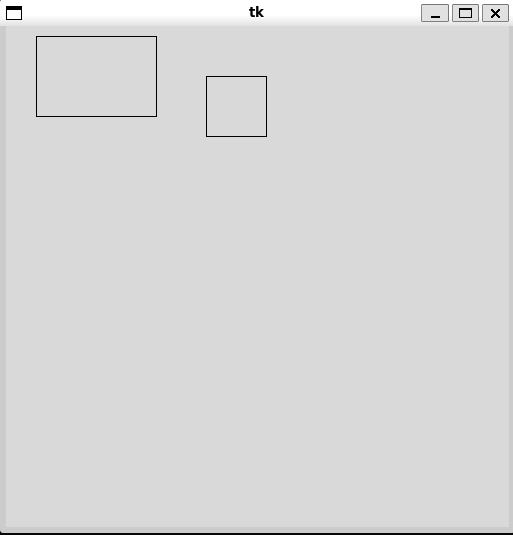
  <figcaption aria-hidden="true">A simple canvas with a rectange and
  square</figcaption>
  </figure>

### Variable Scopes

- Python has four approximate scopes

  1.  Global
      - Visible everywhere
  2.  Class scope
      - Variables defined at the class level
      - Shared across all class instances
  3.  Instance scope
      - Variables defined on the object instance
      - Accessible via the `self`
  4.  Local variables within a function
      - Visible within the function

- This is not a formal explanation of Python’s scoping rules, but rather
  a hueristic to keep in mind

- For example, consider the scope of the variables shown below,

In [7]:
global_variable = "Hello, World!"  # a global variable


class ShowData:
    local_idea = 3.56  # class variable

    def __init__(self, value):
        self._instvar = value

    def method(self):
        method_var = 3
        print("local scope variable:", method_var)
        print("class variable:", ShowData.local_idea)
        print("instance variable:", self._instvar)
        print("Global variable:", global_variable)


d1 = ShowData("Hello")
d1.method()

d2 = ShowData("World")
d2.method()

local scope variable: 3
class variable: 3.56
instance variable: Hello
Global variable: Hello, World!
local scope variable: 3
class variable: 3.56
instance variable: World
Global variable: Hello, World!

#### Properties

- The standard object-oriented mechanism to provide access to private or
  protected instance variables is through *getter* and *setter* methods

In [8]:
class ShowData_2:
    def __init__(self):
        self._instvar = 3.53

    def get_instvar(self):
        return self._instvar

    def set_instvar(self, value):
        self._instvar = value


d1 = ShowData_2()
print("d1.get_instvar():", d1.get_instvar())
print("calling d1.get_instvar(5)")
d1.set_instvar(5)
print("d1.get_instvar():", d1.get_instvar())

d1.get_instvar(): 3.53
calling d1.get_instvar(5)
d1.get_instvar(): 5

- The more pythonic approach is to use *properties*
  - They let you add the functionality of getters and setters while
    keeping the attribute-like access pattern

In [9]:
class ShowData_3:
    def __init__(self):
        self._instvar = 3.53

    @property
    def instvar(self):
        return self._instvar

    @instvar.setter
    def instvar(self, val):
        self._instval = val


d1 = ShowData_3()
print("d1.instvar:", d1.instvar)
print("calling d1.instvar = 5")
d1.instvar = 5
print("d1.instvar:", d1.instvar)

d1.instvar: 3.53
calling d1.instvar = 5
d1.instvar: 3.53

### Types in Python

- Python is dynamically typed
  - Types are deduced at runtime
- Python also follows *duck-typing*
  - The principal being that if an object supports the methods and
    functionality of a given interface then it *is* that type of object
- For stronger type safety, python supports *type hints*
  - Used to allow static type checkers to perform type analysis of
    function calls and methods
  - There are a wide range of tools for type checking that can be
    integrated into development environments
  - Two popular ones are
    1.  MyPy
    2.  Ty
  - Type hints use the syntax of `variable: type`
- For example,

In [10]:
class Summer:
    def add_nums(self, x: float, y: float) -> float:
        print("add_nums(float, float) called")
        return x + y


summer = Summer()
print("summer.add_nums(12.0, 2.3):", summer.add_nums(12.0, 2.3))

add_nums(float, float) called
summer.add_nums(12.0, 2.3): 14.3

- Note, some languages let you define multiple functions with the same
  name but different type signatures
  - This is called function overloading
- Python does not support this by default, the last definition
  overwrites the previous
  - `functools.singledispatch` can be used if you want that
    functionality

## Summary

- Classes are created with the `class` keyword
- Classes combine *data* (attributes) and functions on that data
  (methods)
- Classes can *inherit* methods and attributes from each other in a
  *class hierarchy*
- Subclasses can redefine methods on the superclass.
  - This is a form of *polymorphism*
- Classes can contain other classes